In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchsummary import summary
import numpy as np
import matplotlib.pyplot as plt
import os

In [42]:
# !zip -FF car-brands.zip --out fixed.zip

In [43]:
# !unzip fixed.zip

In [44]:
from pathlib import Path
data_path = Path("")
image_path = data_path / "Car Brand Classification Dataset"

In [45]:
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [46]:
check_data(image_path)

There are 2 directories and 0 images in 'Car Brand Classification Dataset'.
There are 33 directories and 0 images in 'Car Brand Classification Dataset/train'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Nissan'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Ford'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Mitsubishi'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/MINI'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Lexus'.
There are 1 directories and 96 images in 'Car Brand Classification Dataset/train/Volvo'.
There are 0 directories and 0 images in 'Car Brand Classification Dataset/train/Volvo/.ipynb_checkpoints'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Ram'.
There are 0 directories and 349 images in 'Car Brand Classification Dataset/train/Honda'.
There are 0 d

In [47]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [48]:
manual_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

In [49]:
NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir,
    test_dir,
    transform,
    batch_size,
    num_workers=NUM_WORKERS
):
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  class_names = train_data.classes

  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True
  )

  return train_dataloader, test_dataloader, class_names


In [50]:
train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir, test_dir, manual_transforms, batch_size=32)

In [51]:
weights = models.EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights).to("cuda")

In [52]:
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [53]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [54]:
summary(
    model,
    input_size=(3, 224, 224),
    batch_size=32,
    device="cuda"
)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 32, 112, 112]             864
       BatchNorm2d-2         [32, 32, 112, 112]              64
              SiLU-3         [32, 32, 112, 112]               0
            Conv2d-4         [32, 32, 112, 112]             288
       BatchNorm2d-5         [32, 32, 112, 112]              64
              SiLU-6         [32, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [32, 32, 1, 1]               0
            Conv2d-8              [32, 8, 1, 1]             264
              SiLU-9              [32, 8, 1, 1]               0
           Conv2d-10             [32, 32, 1, 1]             288
          Sigmoid-11             [32, 32, 1, 1]               0
SqueezeExcitation-12         [32, 32, 112, 112]               0
           Conv2d-13         [32, 16, 112, 112]             512
      BatchNorm2d-14         [32, 16, 1

In [55]:
for param in model.parameters():
  param.requires_grad = False

In [56]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(class_names)

model.classifier = nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=output_shape, bias=True).to("cuda")
)

In [57]:
summary(
    model,
    input_size=(3, 224, 224),
    batch_size=32,
    device="cuda"
)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [32, 32, 112, 112]             864
       BatchNorm2d-2         [32, 32, 112, 112]              64
              SiLU-3         [32, 32, 112, 112]               0
            Conv2d-4         [32, 32, 112, 112]             288
       BatchNorm2d-5         [32, 32, 112, 112]              64
              SiLU-6         [32, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [32, 32, 1, 1]               0
            Conv2d-8              [32, 8, 1, 1]             264
              SiLU-9              [32, 8, 1, 1]               0
           Conv2d-10             [32, 32, 1, 1]             288
          Sigmoid-11             [32, 32, 1, 1]               0
SqueezeExcitation-12         [32, 32, 112, 112]               0
           Conv2d-13         [32, 16, 112, 112]             512
      BatchNorm2d-14         [32, 16, 1

In [58]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [59]:
def train_step(
    model,
    dataloader,
    loss_fn,
    optimizer,
    device
):
  model.train()
  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    y_pred = model(X)

    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
    train_acc +=   (y_pred_class == y).sum().item() / len(y_pred)

  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

In [60]:
def test_step(
    model,
    dataloader,
    loss_fn,
    device="cuda"
):
  model.eval()

  test_loss, test_acc = 0, 0

  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.to(device), y.to(device)

      test_pred_logits = model(X)

      loss = loss_fn(test_pred_logits, y)
      test_loss += loss.item()

      test_pred_labels = test_pred_logits.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

In [61]:
def train(
    model,
    train_dataloader,
    test_dataloader,
    optimizer,
    loss_fn = nn.CrossEntropyLoss(),
    epochs = 5,
    device="cuda"
):
  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }
  for epoch in range(epochs):
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

    print(f"Epoch: {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [63]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
results = train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=12,
                       device="cuda")
end_time = timer()
total_time = end_time - start_time
print(f"Total training time: {total_time:.3f} seconds")

Epoch: 1 | Train Loss: 2.2432 | Train Acc: 0.3869 | Test Loss: 2.5715 | Test Acc: 0.3249
Epoch: 2 | Train Loss: 2.1867 | Train Acc: 0.4043 | Test Loss: 2.5467 | Test Acc: 0.3309
Epoch: 3 | Train Loss: 2.1620 | Train Acc: 0.4076 | Test Loss: 2.5467 | Test Acc: 0.3305
Epoch: 4 | Train Loss: 2.1307 | Train Acc: 0.4130 | Test Loss: 2.4999 | Test Acc: 0.3450
Epoch: 5 | Train Loss: 2.1209 | Train Acc: 0.4169 | Test Loss: 2.5244 | Test Acc: 0.3401
Epoch: 6 | Train Loss: 2.1913 | Train Acc: 0.3930 | Test Loss: 2.5058 | Test Acc: 0.3450
Epoch: 7 | Train Loss: 2.1696 | Train Acc: 0.3969 | Test Loss: 2.5122 | Test Acc: 0.3594
Epoch: 8 | Train Loss: 2.1467 | Train Acc: 0.4092 | Test Loss: 2.4955 | Test Acc: 0.3542
Epoch: 9 | Train Loss: 2.1175 | Train Acc: 0.4102 | Test Loss: 2.4655 | Test Acc: 0.3618
Epoch: 10 | Train Loss: 2.1005 | Train Acc: 0.4171 | Test Loss: 2.4599 | Test Acc: 0.3662
Epoch: 11 | Train Loss: 2.0744 | Train Acc: 0.4216 | Test Loss: 2.4654 | Test Acc: 0.3694
Epoch: 12 | Train L

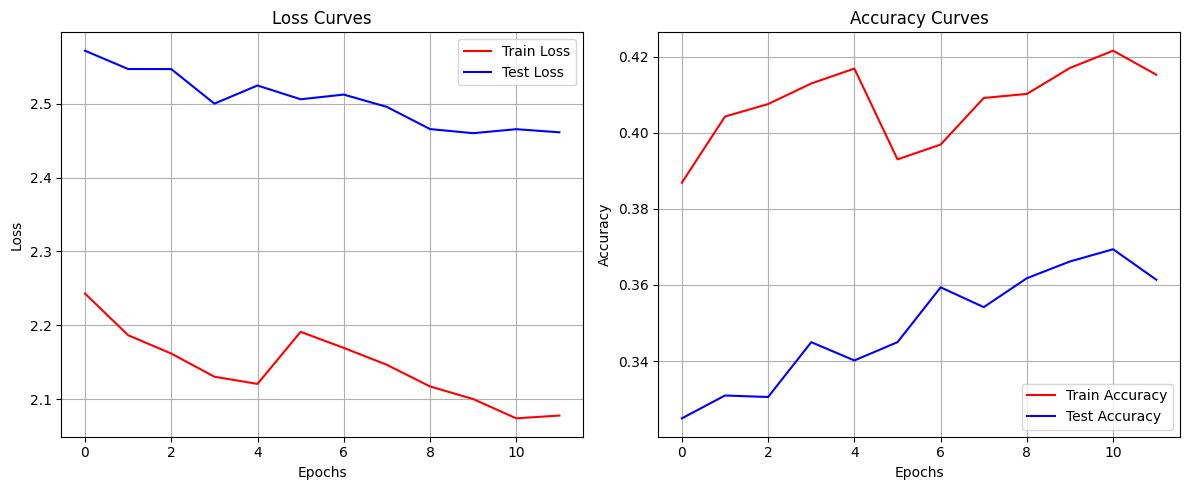

In [66]:
plt.figure(figsize=(12, 5))

# Plot loss curves
plt.subplot(1, 2, 1)
plt.plot(results['train_loss'], label='Train Loss', color='red')
plt.plot(results['test_loss'], label='Test Loss', color='blue')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot accuracy curves
plt.subplot(1, 2, 2)
plt.plot(results['train_acc'], label='Train Accuracy', color='red')
plt.plot(results['test_acc'], label='Test Accuracy', color='blue')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [68]:
from PIL import Image

def predict_single_image(
    image_path: str,
    model: torch.nn.Module,
    class_names: list,
    transform: transforms.Compose,
    device: torch.device
):
    """
    Predicts the class of a single image using a trained model.

    Args:
        image_path (str): The path to the image file.
        model (torch.nn.Module): The trained PyTorch model.
        class_names (list): A list of class names.
        transform (transforms.Compose): The image transformations to apply.
        device (torch.device): The device (e.g., 'cuda' or 'cpu') to run inference on.

    Returns:
        tuple: A tuple containing the predicted class name and the prediction probability.
    """
    # 1. Load the image
    img = Image.open(image_path).convert('RGB') # Ensure image is in RGB format

    # 2. Transform the image
    transformed_img = transform(img).unsqueeze(0).to(device)

    # 3. Put model into evaluation mode and make prediction
    model.eval()
    with torch.inference_mode():
        pred_logits = model(transformed_img)
        pred_probs = torch.softmax(pred_logits, dim=1)
        pred_label = torch.argmax(pred_probs, dim=1)

    # 4. Get predicted class name and probability
    predicted_class_name = class_names[pred_label.cpu().item()]
    prediction_probability = pred_probs.max().cpu().item()

    return predicted_class_name, prediction_probability

Now you can use the `predict_single_image` function. Remember to replace `'path/to/your/image.jpg'` with the actual path to the image you want to test. Also, ensure you have the `manual_transforms` defined or use `auto_transforms` if that was used for inference.

In [72]:
merso_image_path = '/content/merso.jpg'

if os.path.exists(merso_image_path):
    predicted_brand_merso, probability_merso = predict_single_image(
        image_path=merso_image_path,
        model=model,
        class_names=class_names,
        transform=manual_transforms, # Use the same transformations as during training
        device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    )

    print(f"Predicted Brand: {predicted_brand_merso}")
    print(f"Prediction Probability: {probability_merso:.4f}")
else:
    print(f"Error: Image file not found at {merso_image_path}")

Predicted Brand: Audi
Prediction Probability: 0.3704


# False prediction -- Audi - Mercedes